In [1]:
import pandas as pd

data = pd.read_csv("performance.csv")
data = data.drop("amp", axis=1).drop("info", axis=1)
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time"
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
data_left = data

In [2]:
data = pd.read_csv("performance-1-12-9am.csv")
data = data.drop("amp", axis=1)
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time"
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
data_right = data

In [3]:
import warnings

warnings.filterwarnings("ignore")

def normalize(data):
    latency_normalized = []

    for model in model_names:
        subtable = data[data.model == model]
        baseline = subtable[subtable.method == "ReverSyn"].latency.item()
        for method in method_names:
            row = subtable[subtable.method == method]
            row["ratio"] = row.latency.item() / baseline
            latency_normalized.append(row)

    return pd.concat(latency_normalized)

In [4]:
left_normalized = normalize(data_left)
right_normalized = normalize(data_right)

In [5]:
left_normalized

,model,method,latency,memory,cpu_time,gpu_time,acc,ratio
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0,0.987513
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0,1.841791
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0,1.000000
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0,2.261490
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0,0.267658
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0,0.506119
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0,1.000000
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0,0.360613
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0,0.181651
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0,0.874011


In [6]:
right_normalized

,model,method,latency,memory,cpu_time,gpu_time,ratio
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.987513
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,1.841791
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,1.000000
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,2.261490
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.267658
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.506119
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,1.000000
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.360613
10,ResNet164,Original,0.068613,2918.0,165.155,102.952,0.262824
11,ResNet164,SOTA-Revs,0.120468,1964.0,340.794,200.492,0.461456


In [7]:
selected = []

for flag, model in zip("RRRLLRLLR",["ResNet32", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]):
    if flag == "R":
        selected.append(right_normalized[right_normalized.model == model])
    else:
        selected.append(left_normalized[left_normalized.model == model])
        
latency = pd.concat(selected)
latency

,model,method,latency,memory,cpu_time,gpu_time,ratio,acc
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.987513,NaN
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,1.841791,NaN
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,1.000000,NaN
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,2.261490,NaN
20,GPT,Original,0.137831,3242.0,79.252,148.176,0.845306,NaN
21,GPT,SOTA-Revs,0.850464,3680.0,3421.000,2892.000,5.215823,NaN
22,GPT,ReverSyn,0.163055,2220.0,173.571,186.834,1.000000,NaN
23,GPT,Checkpoint,0.158046,2864.0,185.571,156.834,0.969282,NaN
25,Swin,Original,0.263261,1714.0,93.166,34.272,0.898214,NaN
26,Swin,SOTA-Revs,0.302247,1694.0,169.990,45.534,1.031229,NaN


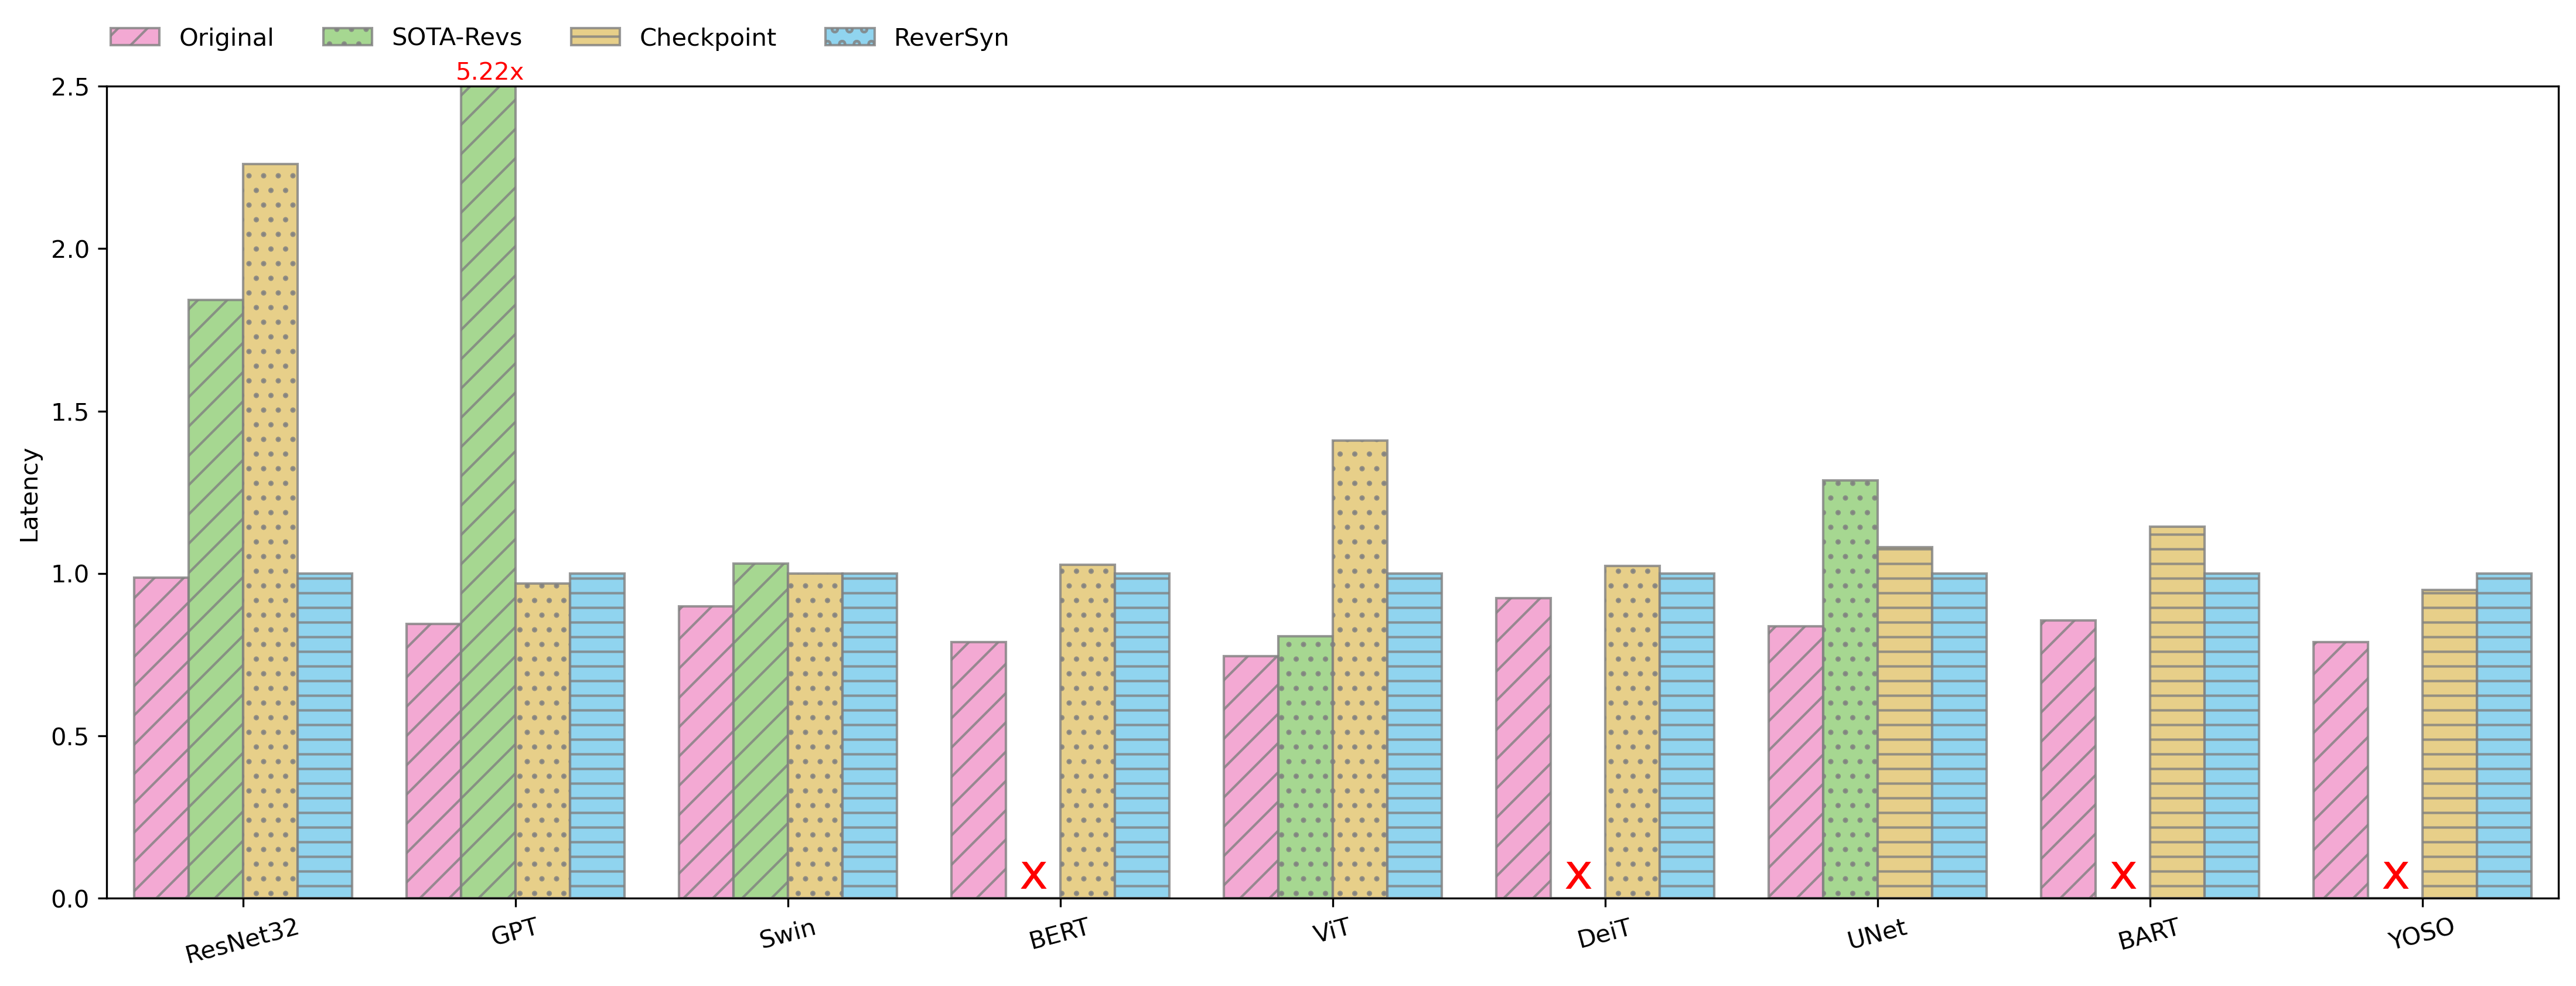

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 6)
ax = sns.barplot(latency, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8)

plt.xlabel(None)
plt.ylabel("Latency")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.1), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0, 2.5)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")

# gpt manual
bar = ax.patches[10]
plt.text(bar.get_x() - 0.02, 2.52, f'{latency[(latency.model == "GPT") & (latency.method == "SOTA-Revs")].ratio.item():.2f}x', color="red")
    
# manual
manual_indices = [12, 14, 16, 17]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.05, 0.03, "x", color="red", fontsize=20)

In [9]:
help(plt.tight_layout)

Help on function tight_layout in module matplotlib.pyplot:

tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)
    Adjust the padding between and around subplots.
    
    To exclude an artist on the Axes from the bounding box calculation
    that determines the subplot parameters (i.e. legend, or annotation),
    set ``a.set_in_layout(False)`` for that artist.
    
    Parameters
    ----------
    pad : float, default: 1.08
        Padding between the figure edge and the edges of subplots,
        as a fraction of the font size.
    h_pad, w_pad : float, default: *pad*
        Padding (height/width) between edges of adjacent subplots,
        as a fraction of the font size.
    rect : tuple (left, bottom, right, top), default: (0, 0, 1, 1)
        A rectangle in normalized figure coordinates into which the whole
        subplots area (including labels) will fit.
    
    See Also
    --------
    .Figure.set_layout_engine
    .pyplot.tight_layout



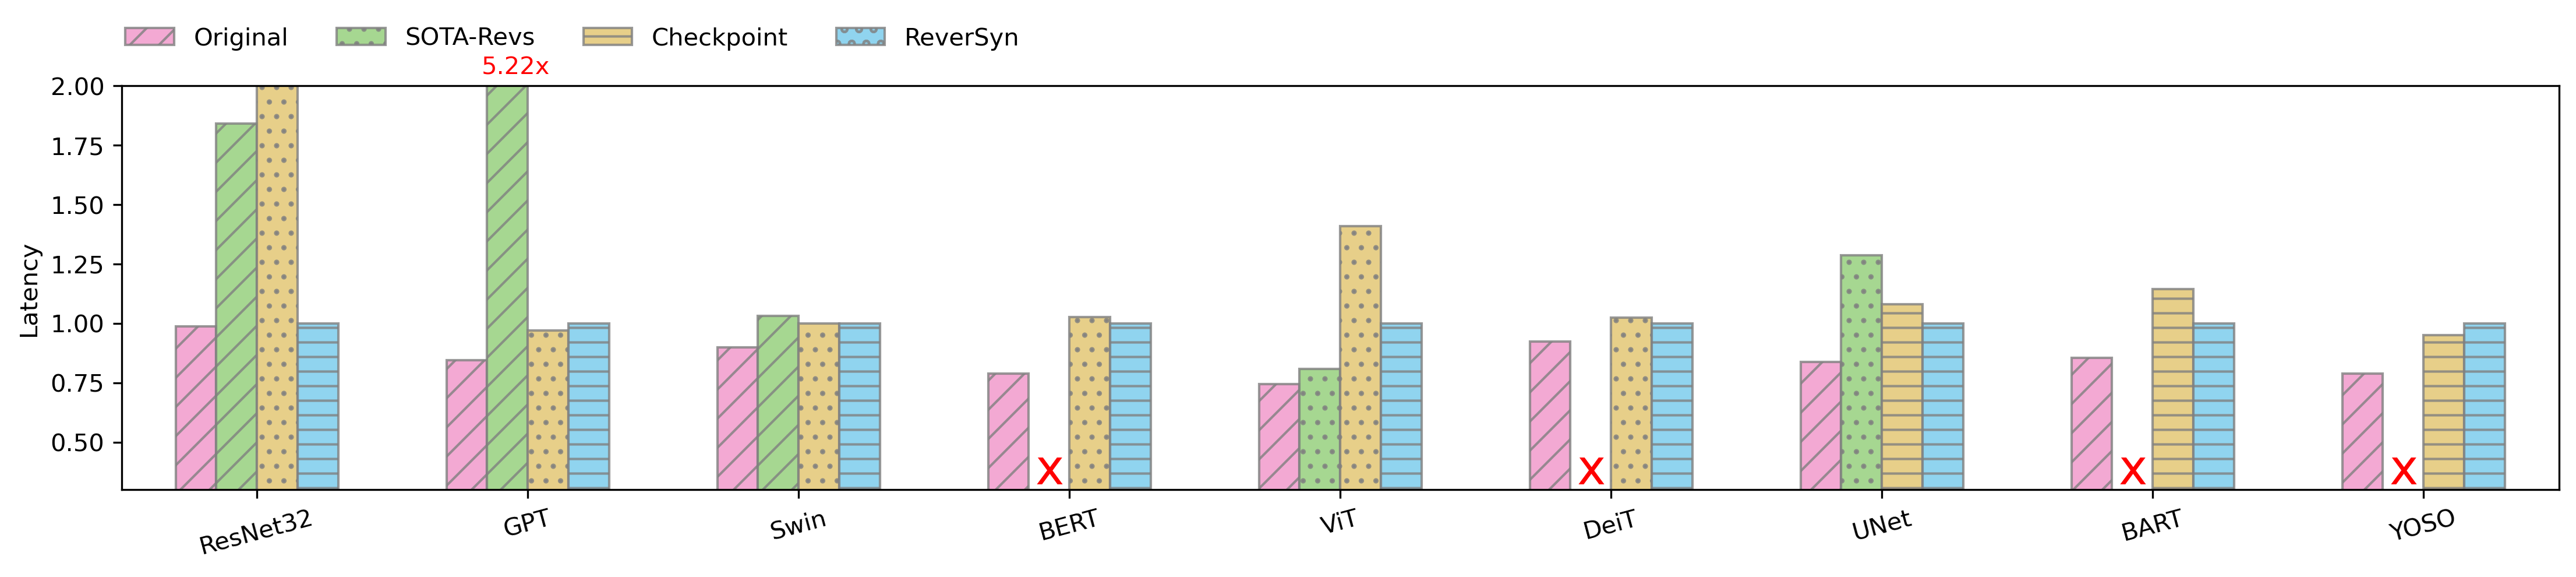

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 3)
ax = sns.barplot(latency, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8, width=0.6)

plt.xlabel(None)
plt.ylabel("Latency")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.2), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0.3, 2.0)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")

# gpt manual
bar = ax.patches[10]
plt.text(bar.get_x() - 0.02, 2.05, f'{latency[(latency.model == "GPT") & (latency.method == "SOTA-Revs")].ratio.item():.2f}x', color="red")
    
# manual
manual_indices = [12, 14, 16, 17]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.025, 0.325, "x", color="red", fontsize=20)
    
plt.subplots_adjust(wspace=1.0)

plt.savefig("latency.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

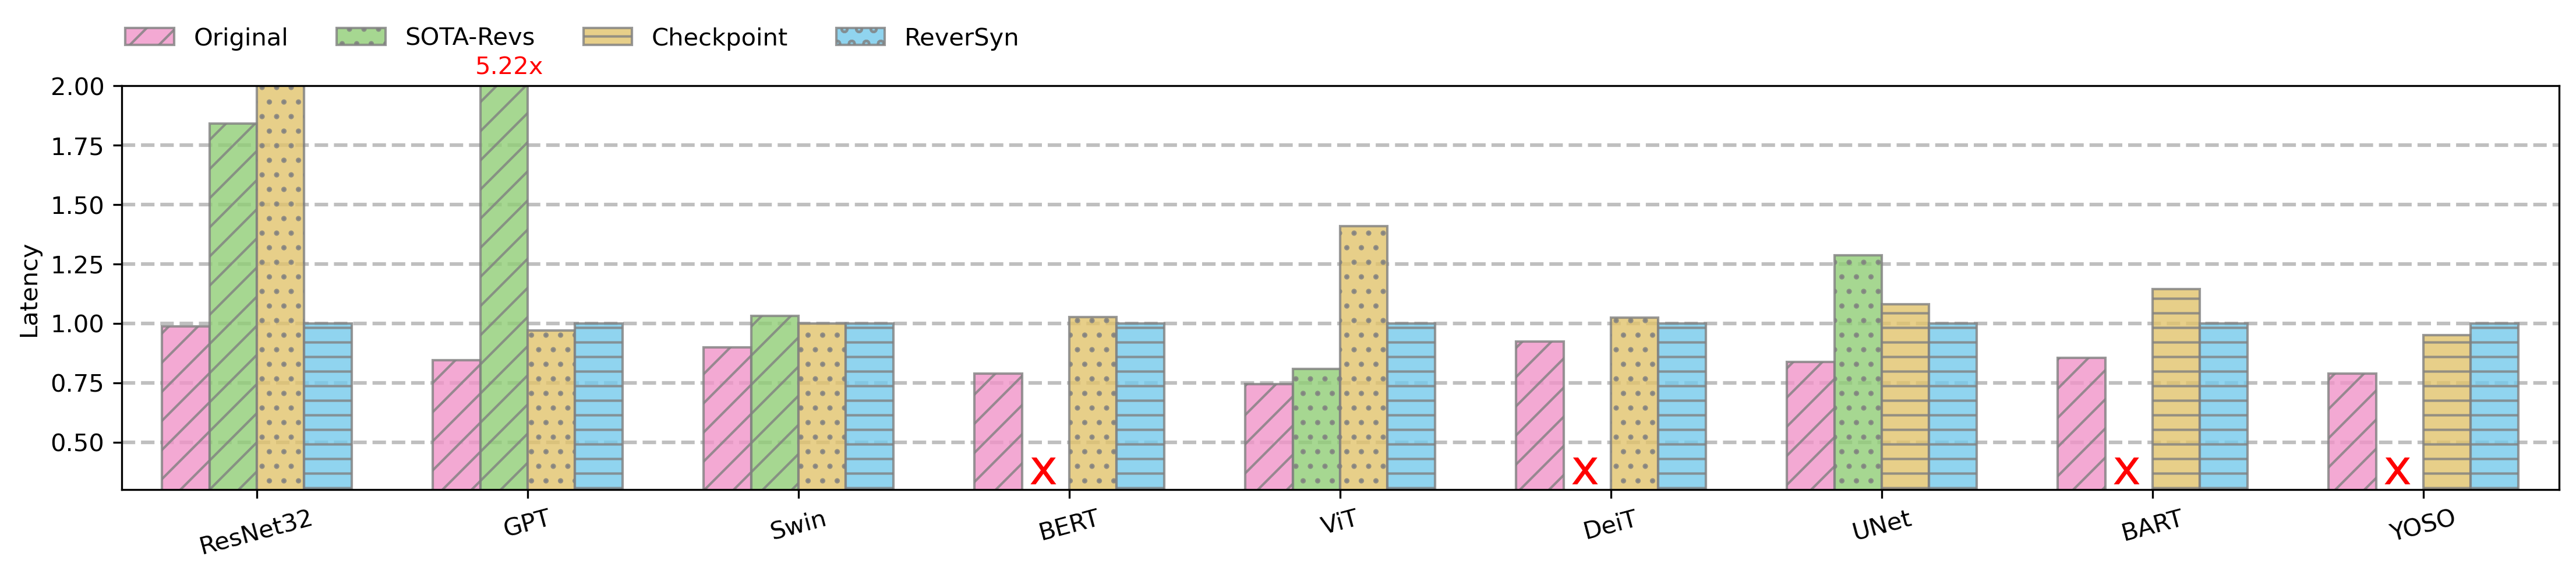

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 3)
ax = sns.barplot(latency, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8, width=0.7)

plt.xlabel(None)
plt.ylabel("Latency")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.2), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0.3, 2.0)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")

# gpt manual
bar = ax.patches[10]
plt.text(bar.get_x() - 0.02, 2.05, f'{latency[(latency.model == "GPT") & (latency.method == "SOTA-Revs")].ratio.item():.2f}x', color="red")
    
# manual
manual_indices = [12, 14, 16, 17]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.025, 0.325, "x", color="red", fontsize=20)
    
plt.subplots_adjust(wspace=1.0)

for y in [0.25 * i for i in range(2, 8)]:
    ax.axhline(y=y, color="gray", linestyle="--", zorder=0, alpha=0.5)

plt.savefig("latency-2.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

In [19]:
latency['throughput'] = 1000 / latency['latency']
# 计算每个model的baseline方法的throughput
baseline_throughput = latency[latency['method'] == 'Original']['throughput']
print(baseline_throughput)

# 使用groupby和transform来计算normalised throughput
latency['normalised_throughput'] = latency.groupby('model')['throughput'].transform(lambda x: x / baseline_throughput)
print(latency)

0     67258.541835
20     7255.261879
25     3798.511743
30     2783.332846
35      761.204164
40     4201.451181
45     2743.089882
50     3235.774725
55     7814.799260
Name: throughput, dtype: float64
       model      method   latency   memory  cpu_time  gpu_time     ratio  \
0   ResNet32    Original  0.014868   1552.0    35.949    18.640  0.987513   
1   ResNet32   SOTA-Revs  0.027730   1500.0    76.855    34.582  1.841791   
2   ResNet32    ReverSyn  0.015056   1470.0    35.930    18.674  1.000000   
3   ResNet32  Checkpoint  0.034049   1500.0    99.575    41.028  2.261490   
20       GPT    Original  0.137831   3242.0    79.252   148.176  0.845306   
21       GPT   SOTA-Revs  0.850464   3680.0  3421.000  2892.000  5.215823   
22       GPT    ReverSyn  0.163055   2220.0   173.571   186.834  1.000000   
23       GPT  Checkpoint  0.158046   2864.0   185.571   156.834  0.969282   
25      Swin    Original  0.263261   1714.0    93.166    34.272  0.898214   
26      Swin   SOTA-Revs  

In [20]:
pd.DataFrame(latency).to_csv("selected_latency.csv")